# Análisis de MAE por segmentos — delay_30m y delay_end

Train: enero–diciembre 2025  
Test: enero 2026  

**Modelo 1 — delay_30m**: viajes con `scheduled_time_to_end >= 1800s` (más de 30 min restantes)  
**Modelo 2 — delay_end**: viajes con `scheduled_time_to_end < 1800s` (menos de 30 min restantes)

Slices analizados en cada modelo:
- Por línea (`route_id`)
- Fin de semana vs laborable
- Hora punta vs no punta (7-9h y 17-19h)
- Por día de semana

In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score

from src.common.minio_client import download_df_parquet

ACCESS_KEY = os.environ['MINIO_ACCESS_KEY']
SECRET_KEY = os.environ['MINIO_SECRET_KEY']

DATA_TEMPLATE = 'grupo5/final/year={year}/month={month:02d}/dataset_final.parquet'
CAT_FEATURES  = ['route_id', 'direction', 'category', 'tipo_referente']
STOP_ID_COL   = 'stop_id'

EXCLUDE_COLS = {
    'date', 'match_key', 'stop_id', 'merge_time', 'timestamp_start',
    'service_date', 'trip_uid', 'is_unscheduled',
    'target_delay_10m', 'target_delay_20m', 'target_delay_30m',
    'target_delay_45m', 'target_delay_60m', 'target_delay_end',
    'delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m',
    'delta_delay_45m', 'delta_delay_60m', 'delta_delay_end',
    'alert_in_next_15m', 'alert_in_next_30m', 'seconds_to_next_alert',
    'delay_minutes', 'scheduled_time', 'actual_time',
    '_route_id', '_dow', '_is_weekend', '_hour', '_is_rush',
}

DOW_NAMES = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves',
             4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}



In [ ]:
# Funciones compartidas

def load_months(year, months, target, filter_col, filter_op):
    """Descarga y filtra datos mensuales desde MinIO.
    filter_op: 'ge' (>=1800) para delay_30m, 'lt' (<1800) para delay_end.
    """
    dfs = []
    for month in months:
        path = DATA_TEMPLATE.format(year=year, month=month)
        try:
            df = download_df_parquet(ACCESS_KEY, SECRET_KEY, path)
            df = df[df['is_unscheduled'] == False]
            df = df.dropna(subset=[target])
            df = df[df[filter_col] >= 1800] if filter_op == 'ge' else df[df[filter_col] < 1800]
            for col in CAT_FEATURES:
                if col in df.columns:
                    df[col] = df[col].astype('category')
            print(f'  {year}-{month:02d}: {len(df):,} filas')
            dfs.append(df)
        except Exception as e:
            print(f'  {year}-{month:02d}: error ({e})')
    return pd.concat(dfs, ignore_index=True)


def add_slice_cols(df):
    """Añade columnas auxiliares para los slices (antes del encode categórico)."""
    df['_route_id']   = df['route_id'].astype(str)
    df['_dow']        = df['dow'].astype(int) if 'dow' in df.columns else -1
    df['_is_weekend'] = df['is_weekend'].astype(int) if 'is_weekend' in df.columns else -1
    if 'hour_sin' in df.columns and 'hour_cos' in df.columns:
        angle = np.arctan2(df['hour_sin'].astype(float), df['hour_cos'].astype(float))
        df['_hour']    = (angle * 24 / (2 * np.pi)) % 24
        df['_is_rush'] = df['_hour'].apply(lambda h: 1 if (7 <= h < 9) or (17 <= h < 19) else 0)
    return df


def encode_categoricals(df_tr, df_te):
    """Label encoding con vocabulario de train; desconocidos en test → -1."""
    for col in CAT_FEATURES:
        if col not in df_tr.columns:
            continue
        vocab = {v: i for i, v in enumerate(df_tr[col].astype(str).unique())}
        df_tr[col] = df_tr[col].astype(str).map(vocab).astype(int)
        df_te[col] = df_te[col].astype(str).map(vocab).fillna(-1).astype(int)
    return df_tr, df_te


def add_target_encoding(df_tr, df_te, col, target):
    """Target encoding de stop_id: media del target en train, fallback a media global."""
    means = df_tr.groupby(col)[target].mean()
    df_tr[f'{col}_target_enc'] = df_tr[col].map(means)
    df_te[f'{col}_target_enc'] = df_te[col].map(means).fillna(df_tr[target].mean())
    return df_tr, df_te


def add_derived_features(df):
    """Features derivadas: velocidad, aceleración, interacción retraso×paradas, ratio."""
    if 'lagged_delay_1' in df.columns and 'delay_seconds' in df.columns:
        df['delay_velocity'] = df['delay_seconds'] - df['lagged_delay_1']
    if 'lagged_delay_1' in df.columns and 'lagged_delay_2' in df.columns:
        df['delay_acceleration'] = (
            (df['delay_seconds'] - df['lagged_delay_1'])
            - (df['lagged_delay_1'] - df['lagged_delay_2'])
        )
    if 'delay_seconds' in df.columns and 'stops_to_end' in df.columns:
        df['delay_x_stops_remaining'] = df['delay_seconds'] * df['stops_to_end']
    if 'delay_seconds' in df.columns and 'scheduled_time_to_end' in df.columns:
        df['delay_ratio'] = df['delay_seconds'] / (df['scheduled_time_to_end'] + 1)
    return df


def get_features(df, target):
    """Devuelve columnas usables como features (excluye targets, IDs y auxiliares)."""
    return [c for c in df.columns if c not in EXCLUDE_COLS and c != target]


def compute_slices(df_in, target, mae_global):
    """Calcula MAE, R² y sesgo por segmento (línea, fin de semana, hora punta, día).
    """
    df = df_in.copy()
    df['_y'] = df[target]

    def _stats(g):
        return pd.Series({
            'n_filas': len(g),
            'mae_s':   mean_absolute_error(g['_y'], g['_pred']),
            'mae_min': mean_absolute_error(g['_y'], g['_pred']) / 60,
            'r2':      r2_score(g['_y'], g['_pred']),
            'bias_s':  (g['_pred'] - g['_y']).mean(),
        })

    by_line = (df.groupby('_route_id').apply(_stats)
               .reset_index().rename(columns={'_route_id': 'linea'})
               .sort_values('mae_s', ascending=False))

    we_map   = {0: 'Laborable', 1: 'Fin de semana'}
    rush_map = {0: 'Fuera de punta', 1: 'Hora punta'}

    by_we = (df.groupby('_is_weekend').apply(_stats)
             .reset_index()
             .assign(tipo=lambda d: d['_is_weekend'].map(we_map))
             .drop(columns='_is_weekend'))

    by_rush = (df.groupby('_is_rush').apply(_stats)
               .reset_index()
               .assign(tipo=lambda d: d['_is_rush'].map(rush_map))
               .drop(columns='_is_rush'))

    by_dow = (df.groupby('_dow').apply(_stats)
              .reset_index()
              .assign(dia=lambda d: d['_dow'].map(DOW_NAMES))
              .drop(columns='_dow'))

    return by_line, by_we, by_rush, by_dow


def plot_slices(by_line, by_we, by_rush, by_dow, mae_global, title_prefix):
    """Gráfico 2×2 con MAE por segmento. Rojo = por encima del global, azul = por debajo."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'{title_prefix} — MAE por segmento  (global: {mae_global:.0f}s)', fontsize=13)

    for ax, df, xcol, title in [
        (axes[0, 0], by_line,  'linea', 'Por línea'),
        (axes[0, 1], by_we,   'tipo',  'Laborable vs Fin de semana'),
        (axes[1, 0], by_rush, 'tipo',  'Hora punta vs Fuera de punta'),
        (axes[1, 1], by_dow,  'dia',   'Por día de la semana'),
    ]:
        colors = ['tomato' if m > mae_global else 'steelblue' for m in df['mae_s']]
        ax.bar(df[xcol], df['mae_s'], color=colors)
        ax.axhline(mae_global, color='black', linestyle='--', linewidth=1.2,
                   label=f'Global: {mae_global:.0f}s')
        ax.set_title(title)
        ax.set_ylabel('MAE (s)')
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()



Funciones cargadas.


In [21]:
# Hotfix memoria: evita df.copy() sobre millones de filas en compute_slices
def compute_slices(df_in, target, mae_global=None):
    """Calcula MAE, R² y sesgo por segmento con bajo uso de memoria.
    mae_global se mantiene por compatibilidad de firma.
    """
    required = ['_pred', target, '_route_id', '_is_weekend', '_is_rush', '_dow']
    missing = [c for c in required if c not in df_in.columns]
    if missing:
        raise KeyError(f'Faltan columnas para compute_slices: {missing}')

    # Solo referencias a columnas necesarias; evita duplicar el DataFrame completo
    slice_df = df_in[required]

    def _stats(g):
        y = g[target].to_numpy(copy=False)
        p = g['_pred'].to_numpy(copy=False)
        err = p - y

        mae_s = float(np.abs(err).mean())
        mae_min = mae_s / 60.0
        bias_s = float(err.mean())

        ss_res = float(np.square(err).sum())
        y_centered = y - y.mean()
        ss_tot = float(np.square(y_centered).sum())
        r2 = float(1 - (ss_res / ss_tot)) if ss_tot > 0 else np.nan

        return pd.Series({
            'n_filas': len(g),
            'mae_s': mae_s,
            'mae_min': mae_min,
            'r2': r2,
            'bias_s': bias_s,
        })

    by_line = (slice_df.groupby('_route_id', observed=True).apply(_stats)
               .reset_index().rename(columns={'_route_id': 'linea'})
               .sort_values('mae_s', ascending=False))

    we_map = {0: 'Laborable', 1: 'Fin de semana'}
    rush_map = {0: 'Fuera de punta', 1: 'Hora punta'}

    by_we = (slice_df.groupby('_is_weekend', observed=True).apply(_stats)
             .reset_index()
             .assign(tipo=lambda d: d['_is_weekend'].map(we_map))
             .drop(columns='_is_weekend'))

    by_rush = (slice_df.groupby('_is_rush', observed=True).apply(_stats)
               .reset_index()
               .assign(tipo=lambda d: d['_is_rush'].map(rush_map))
               .drop(columns='_is_rush'))

    by_dow = (slice_df.groupby('_dow', observed=True).apply(_stats)
              .reset_index()
              .assign(dia=lambda d: d['_dow'].map(DOW_NAMES))
              .drop(columns='_dow'))

    return by_line, by_we, by_rush, by_dow

print('compute_slices optimizado cargado (sin copia completa de dataframe).')

compute_slices optimizado cargado (sin copia completa de dataframe).


---
# Parte 1: delay_30m
`scheduled_time_to_end >= 1800s`

In [4]:
TARGET_30M = 'target_delay_30m'

LGBM_PARAMS_30M = {
    'objective': 'regression_l1', 'metric': 'mae',
    'learning_rate': 0.05, 'num_leaves': 511, 'max_depth': 16,
    'min_child_samples': 100, 'min_split_gain': 0.37042771510661165,
    'feature_fraction': 0.7426288737567357, 'bagging_fraction': 0.8165370010747616,
    'bagging_freq': 5, 'reg_alpha': 1.5346393797283635,
    'reg_lambda': 1.2926631392622208, 'n_jobs': -1, 'verbose': -1, 'seed': 42,
}
NUM_BOOST_ROUND_30M = 4260

print('Cargando train 2025 (delay_30m)...')
tr30 = load_months(2025, range(1, 13), TARGET_30M, 'scheduled_time_to_end', 'ge')
print(f'  Total train: {len(tr30):,} filas\n')

print('Cargando test ene 2026 (delay_30m)...')
te30 = load_months(2026, range(1, 2), TARGET_30M, 'scheduled_time_to_end', 'ge')
print(f'  Total test:  {len(te30):,} filas')

Cargando train 2025 (delay_30m)...
  2025-01: 1,299,597 filas
  2025-02: 1,264,121 filas
  2025-03: 1,430,801 filas
  2025-04: 1,320,703 filas
  2025-05: 1,232,441 filas
  2025-06: 1,287,542 filas
  2025-07: 1,320,327 filas
  2025-08: 1,386,955 filas
  2025-09: 1,410,181 filas
  2025-10: 1,500,119 filas
  2025-11: 1,424,947 filas
  2025-12: 1,545,659 filas
  Total train: 16,423,393 filas

Cargando test ene 2026 (delay_30m)...
  2026-01: 1,417,549 filas
  Total test:  1,417,549 filas


In [ ]:
tr30 = add_slice_cols(tr30)  
te30 = add_slice_cols(te30)
tr30, te30 = encode_categoricals(tr30, te30)
tr30, te30 = add_target_encoding(tr30, te30, STOP_ID_COL, TARGET_30M)
tr30 = add_derived_features(tr30)
te30 = add_derived_features(te30)

feats30 = get_features(tr30, TARGET_30M)
print(f'Features: {len(feats30)}  →  {feats30}')

Features: 31  →  ['route_id', 'direction', 'delay_seconds', 'lagged_delay_1', 'lagged_delay_2', 'route_rolling_delay', 'actual_headway_seconds', 'hour_sin', 'hour_cos', 'dow', 'is_weekend', 'station_delay_10m', 'station_delay_20m', 'station_delay_30m', 'stops_to_end', 'scheduled_time_to_end', 'temp_extreme', 'n_eventos_afectando', 'tipo_referente', 'afecta_previo', 'afecta_durante', 'afecta_despues', 'category', 'num_updates', 'seconds_since_last_alert', 'is_alert_just_published', 'stop_id_target_enc', 'delay_velocity', 'delay_acceleration', 'delay_x_stops_remaining', 'delay_ratio']


In [6]:
X_tr30, y_tr30 = tr30[feats30], tr30[TARGET_30M]
X_te30, y_te30 = te30[feats30], te30[TARGET_30M]

print(f'Entrenando LGBM delay_30m ({NUM_BOOST_ROUND_30M} iters)...')
model30 = lgb.train(
    LGBM_PARAMS_30M,
    lgb.Dataset(X_tr30, label=y_tr30),
    num_boost_round=NUM_BOOST_ROUND_30M,
    callbacks=[lgb.log_evaluation(500)],
)

tr30['_pred'] = model30.predict(X_tr30)
te30['_pred'] = model30.predict(X_te30)

mae30_train = mean_absolute_error(y_tr30, tr30['_pred'])
r2_30_train = r2_score(y_tr30, tr30['_pred'])
mae30       = mean_absolute_error(y_te30, te30['_pred'])
r2_30       = r2_score(y_te30, te30['_pred'])

print(f'\nMétricas delay_30m:')
print(f'  Train (ene-dic 2025): MAE={mae30_train:.2f}s  ({mae30_train/60:.2f} min)  |  R²={r2_30_train:.4f}')
print(f'  Test  (ene 2026):     MAE={mae30:.2f}s  ({mae30/60:.2f} min)  |  R²={r2_30:.4f}')
print(f'  Gap train→test:       {mae30 - mae30_train:+.1f}s')

Entrenando LGBM delay_30m (4260 iters)...

Métricas delay_30m:
  Train (ene-dic 2025): MAE=116.10s  (1.93 min)  |  R²=0.6334
  Test  (ene 2026):     MAE=134.28s  (2.24 min)  |  R²=0.5751
  Gap train→test:       +18.2s


=== delay_30m — MAE global  train: 116.1s  |  test: 134.3s ===

-- Por línea --
linea  mae_train_s  mae_test_s  gap_s
    4        116.0       206.3   90.3
   FX        110.9       202.0   91.1
    3         88.7       183.8   95.1
    E        146.6       165.7   19.1
   SI        167.4       164.1   -3.3
    2         93.5       160.1   66.6
    B        114.1       148.6   34.5
    N        125.6       143.9   18.3
    W        115.1       143.8   28.6
    F        126.6       143.0   16.5
    A        116.9       138.3   21.4
    Q        111.0       130.8   19.8
    R        117.5       129.6   12.1
    M        122.7       126.7    4.1
    J        106.1       125.7   19.6
    Z         86.3       122.5   36.2
    C         96.9       118.7   21.9
    D         91.9       111.7   19.8
    6         65.6       111.1   45.5
    G         87.9       102.7   14.8
    1         76.3        77.8    1.6

-- Laborable vs Fin de semana --
         tipo  mae_train_s  mae_test_s  gap_s
    

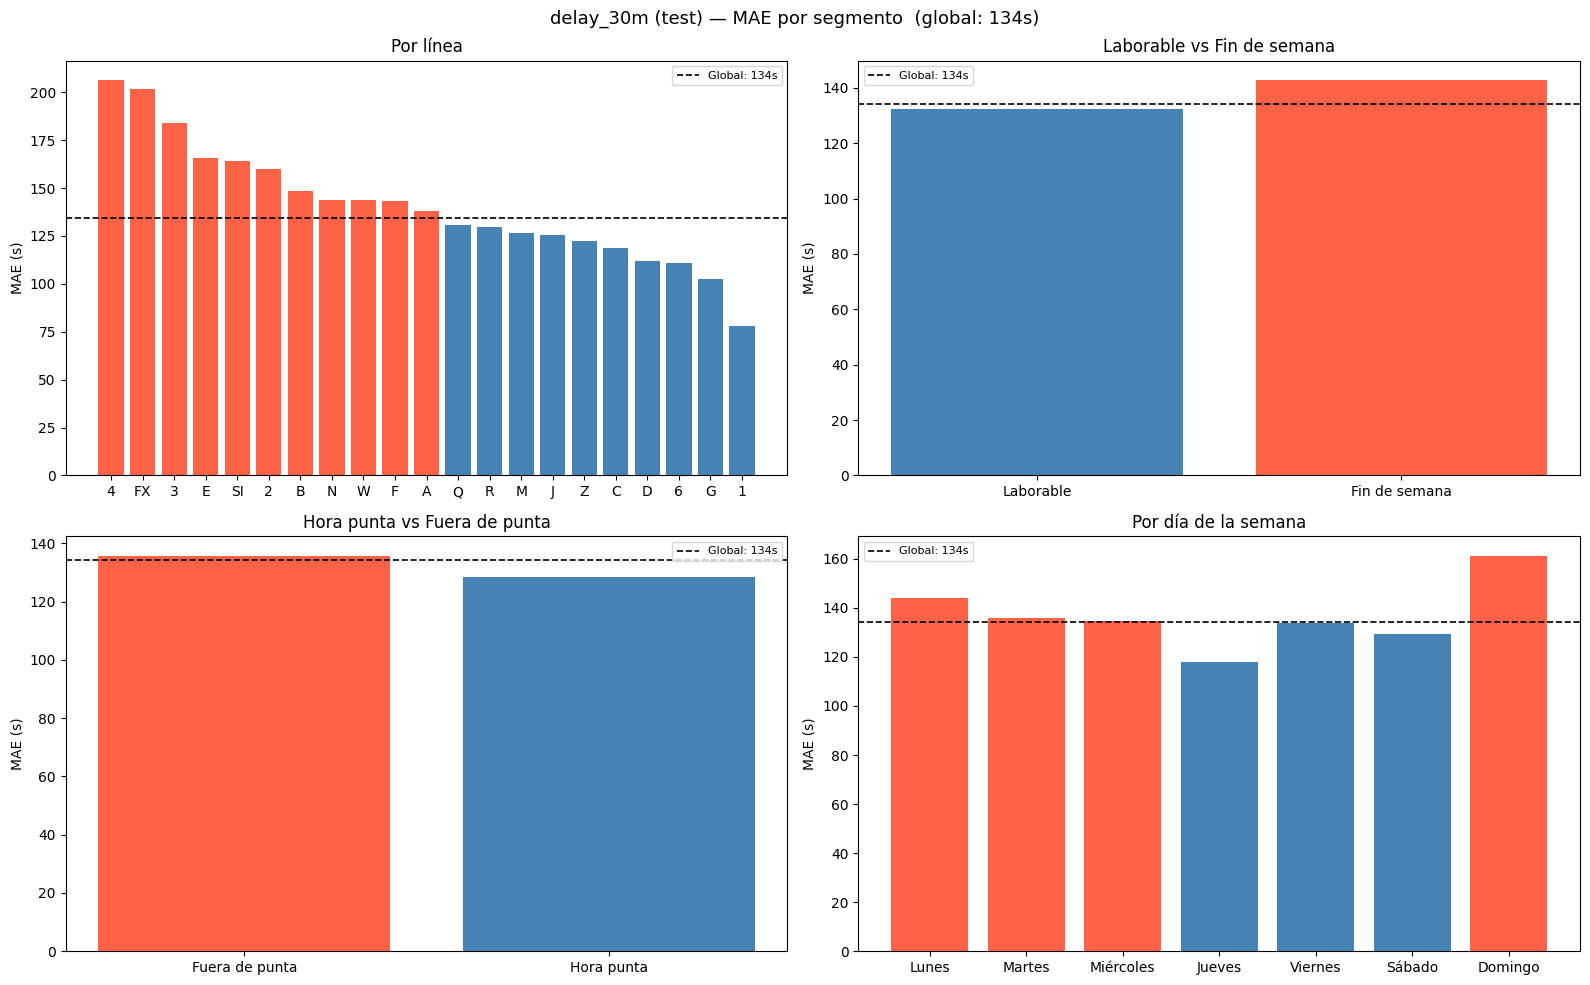

In [7]:
bl30,   we30,   rush30,   dow30   = compute_slices(te30, TARGET_30M, mae30)
bl30_tr, we30_tr, rush30_tr, dow30_tr = compute_slices(tr30, TARGET_30M, mae30_train)

print(f'=== delay_30m — MAE global  train: {mae30_train:.1f}s  |  test: {mae30:.1f}s ===\n')

print('-- Por línea --')
comp_line30 = bl30_tr[['linea','mae_s']].rename(columns={'mae_s':'mae_train_s'}).merge(
    bl30[['linea','mae_s']].rename(columns={'mae_s':'mae_test_s'}), on='linea')
comp_line30['gap_s'] = (comp_line30['mae_test_s'] - comp_line30['mae_train_s']).round(1)
print(comp_line30.sort_values('mae_test_s', ascending=False).round(1).to_string(index=False))

print('\n-- Laborable vs Fin de semana --')
comp_we30 = we30_tr[['tipo','mae_s']].rename(columns={'mae_s':'mae_train_s'}).merge(
    we30[['tipo','mae_s']].rename(columns={'mae_s':'mae_test_s'}), on='tipo')
comp_we30['gap_s'] = (comp_we30['mae_test_s'] - comp_we30['mae_train_s']).round(1)
print(comp_we30.round(1).to_string(index=False))

print('\n-- Hora punta vs Fuera de punta --')
comp_rush30 = rush30_tr[['tipo','mae_s']].rename(columns={'mae_s':'mae_train_s'}).merge(
    rush30[['tipo','mae_s']].rename(columns={'mae_s':'mae_test_s'}), on='tipo')
comp_rush30['gap_s'] = (comp_rush30['mae_test_s'] - comp_rush30['mae_train_s']).round(1)
print(comp_rush30.round(1).to_string(index=False))

print('\n-- Por día de semana --')
comp_dow30 = dow30_tr[['dia','mae_s']].rename(columns={'mae_s':'mae_train_s'}).merge(
    dow30[['dia','mae_s']].rename(columns={'mae_s':'mae_test_s'}), on='dia')
comp_dow30['gap_s'] = (comp_dow30['mae_test_s'] - comp_dow30['mae_train_s']).round(1)
print(comp_dow30.round(1).to_string(index=False))

plot_slices(bl30, we30, rush30, dow30, mae30, 'delay_30m (test)')

---
# Parte 2: delay_end
`scheduled_time_to_end < 1800s`

In [8]:
TARGET_END = 'target_delay_end'

LGBM_PARAMS_END = {
    'objective': 'regression_l1', 'metric': 'mae',
    'learning_rate': 0.1, 'num_leaves': 511, 'max_depth': -1,
    'min_child_samples': 200, 'min_split_gain': 0.4288084220895492,
    'feature_fraction': 0.924842417292814, 'bagging_fraction': 0.7040148314775926,
    'bagging_freq': 5, 'reg_alpha': 1.5122983878652498,
    'reg_lambda': 0.9403505804168345, 'n_jobs': -1, 'verbose': -1, 'seed': 42,
}
NUM_BOOST_ROUND_END = 6299

print('Cargando train 2025 (delay_end)...')
tr_end = load_months(2025, range(1, 13), TARGET_END, 'scheduled_time_to_end', 'lt')
print(f'  Total train: {len(tr_end):,} filas\n')

print('Cargando test ene 2026 (delay_end)...')
te_end = load_months(2026, range(1, 2), TARGET_END, 'scheduled_time_to_end', 'lt')
print(f'  Total test:  {len(te_end):,} filas')

Cargando train 2025 (delay_end)...
  2025-01: 3,360,834 filas
  2025-02: 3,018,562 filas
  2025-03: 2,606,442 filas
  2025-04: 3,220,329 filas
  2025-05: 3,287,707 filas
  2025-06: 3,162,105 filas
  2025-07: 3,304,915 filas
  2025-08: 3,270,916 filas
  2025-09: 3,214,544 filas
  2025-10: 3,399,953 filas
  2025-11: 3,026,002 filas
  2025-12: 3,324,163 filas
  Total train: 38,196,472 filas

Cargando test ene 2026 (delay_end)...
  2026-01: 3,189,151 filas
  Total test:  3,189,151 filas


In [9]:
tr_end = add_slice_cols(tr_end)   
te_end = add_slice_cols(te_end)
tr_end, te_end = encode_categoricals(tr_end, te_end)
tr_end, te_end = add_target_encoding(tr_end, te_end, STOP_ID_COL, TARGET_END)
tr_end = add_derived_features(tr_end)
te_end = add_derived_features(te_end)

feats_end = get_features(tr_end, TARGET_END)
print(f'Features: {len(feats_end)}  →  {feats_end}')

Features: 31  →  ['route_id', 'direction', 'delay_seconds', 'lagged_delay_1', 'lagged_delay_2', 'route_rolling_delay', 'actual_headway_seconds', 'hour_sin', 'hour_cos', 'dow', 'is_weekend', 'station_delay_10m', 'station_delay_20m', 'station_delay_30m', 'stops_to_end', 'scheduled_time_to_end', 'temp_extreme', 'n_eventos_afectando', 'tipo_referente', 'afecta_previo', 'afecta_durante', 'afecta_despues', 'category', 'num_updates', 'seconds_since_last_alert', 'is_alert_just_published', 'stop_id_target_enc', 'delay_velocity', 'delay_acceleration', 'delay_x_stops_remaining', 'delay_ratio']


In [10]:
X_tr_end, y_tr_end = tr_end[feats_end], tr_end[TARGET_END]
X_te_end, y_te_end = te_end[feats_end], te_end[TARGET_END]

print(f'Entrenando LGBM delay_end ({NUM_BOOST_ROUND_END} iters)...')
model_end = lgb.train(
    LGBM_PARAMS_END,
    lgb.Dataset(X_tr_end, label=y_tr_end),
    num_boost_round=NUM_BOOST_ROUND_END,
    callbacks=[lgb.log_evaluation(500)],
)

tr_end['_pred'] = model_end.predict(X_tr_end)
te_end['_pred'] = model_end.predict(X_te_end)

mae_end_train = mean_absolute_error(y_tr_end, tr_end['_pred'])
r2_end_train  = r2_score(y_tr_end, tr_end['_pred'])
mae_end       = mean_absolute_error(y_te_end, te_end['_pred'])
r2_end        = r2_score(y_te_end, te_end['_pred'])

print(f'\nMétricas delay_end:')
print(f'  Train (ene-dic 2025): MAE={mae_end_train:.2f}s  ({mae_end_train/60:.2f} min)  |  R²={r2_end_train:.4f}')
print(f'  Test  (ene 2026):     MAE={mae_end:.2f}s  ({mae_end/60:.2f} min)  |  R²={r2_end:.4f}')
print(f'  Gap train→test:       {mae_end - mae_end_train:+.1f}s')

Entrenando LGBM delay_end (6299 iters)...

Métricas delay_end:
  Train (ene-dic 2025): MAE=96.58s  (1.61 min)  |  R²=0.7263
  Test  (ene 2026):     MAE=109.03s  (1.82 min)  |  R²=0.7116
  Gap train→test:       +12.4s


=== delay_end — MAE global  train: 96.6s  |  test: 109.0s ===

-- Por línea --
linea  mae_train_s  mae_test_s  gap_s
   SI        359.7       420.6   60.8
    2        146.3       156.5   10.3
   FX         96.7       153.7   57.0
    5        123.6       139.3   15.7
    B         94.2       130.4   36.2
    3        111.4       128.2   16.8
    N        103.3       126.5   23.3
    4        111.3       120.8    9.5
    F        101.6       118.3   16.7
    W         76.7       111.9   35.2
    Q         85.2       104.1   19.0
    E         88.1        99.3   11.2
    6         85.5        97.9   12.4
   6X         80.1        95.5   15.5
    A         72.8        93.3   20.5
    R         83.0        92.1    9.1
    1         83.4        88.0    4.6
    Z         64.1        86.9   22.8
    C         67.9        79.1   11.2
    G         66.0        75.2    9.3
    J         48.8        75.0   26.2
    M         68.6        68.5   -0.2
    D         51.5        65.7   14.2
   FS    

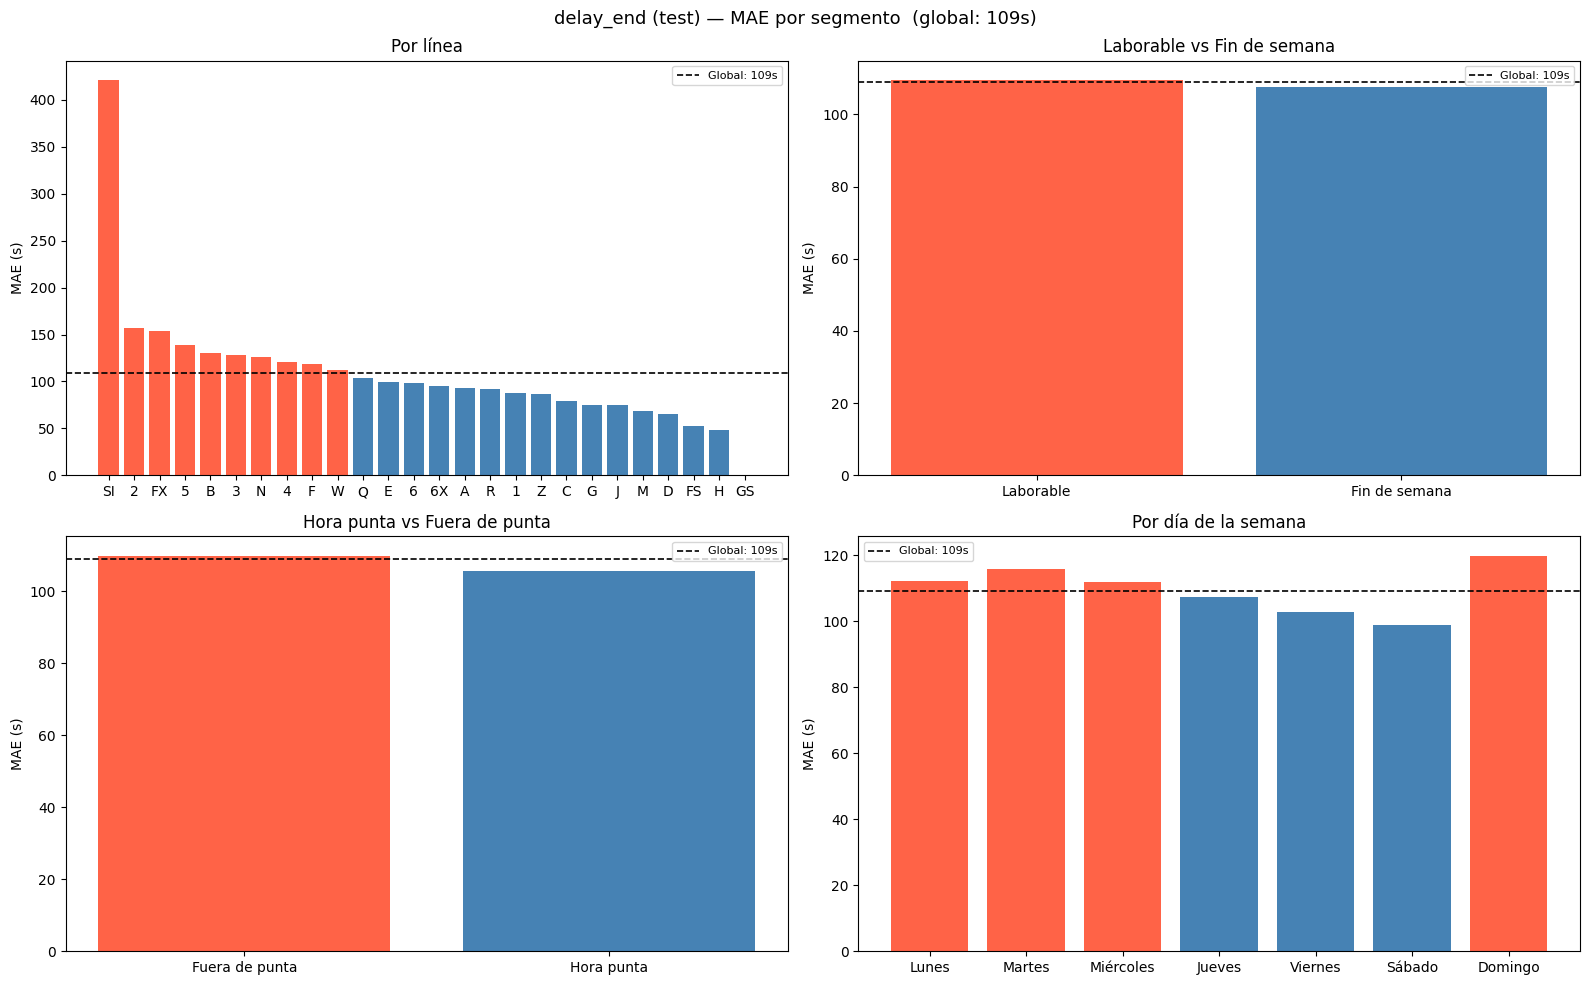

In [22]:
bl_end,    we_end,    rush_end,    dow_end    = compute_slices(te_end, TARGET_END, mae_end)
bl_end_tr, we_end_tr, rush_end_tr, dow_end_tr = compute_slices(tr_end, TARGET_END, mae_end_train)

print(f'=== delay_end — MAE global  train: {mae_end_train:.1f}s  |  test: {mae_end:.1f}s ===\n')

print('-- Por línea --')
comp_line_end = bl_end_tr[['linea','mae_s']].rename(columns={'mae_s':'mae_train_s'}).merge(
    bl_end[['linea','mae_s']].rename(columns={'mae_s':'mae_test_s'}), on='linea')
comp_line_end['gap_s'] = (comp_line_end['mae_test_s'] - comp_line_end['mae_train_s']).round(1)
print(comp_line_end.sort_values('mae_test_s', ascending=False).round(1).to_string(index=False))

print('\n-- Laborable vs Fin de semana --')
comp_we_end = we_end_tr[['tipo','mae_s']].rename(columns={'mae_s':'mae_train_s'}).merge(
    we_end[['tipo','mae_s']].rename(columns={'mae_s':'mae_test_s'}), on='tipo')
comp_we_end['gap_s'] = (comp_we_end['mae_test_s'] - comp_we_end['mae_train_s']).round(1)
print(comp_we_end.round(1).to_string(index=False))

print('\n-- Hora punta vs Fuera de punta --')
comp_rush_end = rush_end_tr[['tipo','mae_s']].rename(columns={'mae_s':'mae_train_s'}).merge(
    rush_end[['tipo','mae_s']].rename(columns={'mae_s':'mae_test_s'}), on='tipo')
comp_rush_end['gap_s'] = (comp_rush_end['mae_test_s'] - comp_rush_end['mae_train_s']).round(1)
print(comp_rush_end.round(1).to_string(index=False))

print('\n-- Por día de semana --')
comp_dow_end = dow_end_tr[['dia','mae_s']].rename(columns={'mae_s':'mae_train_s'}).merge(
    dow_end[['dia','mae_s']].rename(columns={'mae_s':'mae_test_s'}), on='dia')
comp_dow_end['gap_s'] = (comp_dow_end['mae_test_s'] - comp_dow_end['mae_train_s']).round(1)
print(comp_dow_end.round(1).to_string(index=False))

plot_slices(bl_end, we_end, rush_end, dow_end, mae_end, 'delay_end (test)')

---
# Resumen comparativo

In [23]:
print('=' * 65)
print('RESUMEN GLOBAL')
print('=' * 65)
print(f'{"":25} {"delay_30m":>15} {"delay_end":>15}')
print(f'{"Train MAE (s)":25} {mae30_train:>15.1f} {mae_end_train:>15.1f}')
print(f'{"Train MAE (min)":25} {mae30_train/60:>15.2f} {mae_end_train/60:>15.2f}')
print(f'{"Train R²":25} {r2_30_train:>15.4f} {r2_end_train:>15.4f}')
print(f'{"Test MAE (s)":25} {mae30:>15.1f} {mae_end:>15.1f}')
print(f'{"Test MAE (min)":25} {mae30/60:>15.2f} {mae_end/60:>15.2f}')
print(f'{"Test R²":25} {r2_30:>15.4f} {r2_end:>15.4f}')
print(f'{"Gap train→test (s)":25} {mae30 - mae30_train:>+15.1f} {mae_end - mae_end_train:>+15.1f}')
print('=' * 65)

print('\n--- Laborable vs Fin de semana (test) ---')
comp_we = comp_we30[['tipo','mae_train_s','mae_test_s']].merge(
    comp_we_end[['tipo','mae_train_s','mae_test_s']], on='tipo', suffixes=('_30m','_end'))
print(comp_we.round(1).to_string(index=False))

print('\n--- Hora punta vs Fuera de punta (test) ---')
comp_rush = comp_rush30[['tipo','mae_train_s','mae_test_s']].merge(
    comp_rush_end[['tipo','mae_train_s','mae_test_s']], on='tipo', suffixes=('_30m','_end'))
print(comp_rush.round(1).to_string(index=False))

print('\n--- Por día de semana (test) ---')
comp_dow = comp_dow30[['dia','mae_train_s','mae_test_s']].merge(
    comp_dow_end[['dia','mae_train_s','mae_test_s']], on='dia', suffixes=('_30m','_end'))
print(comp_dow.round(1).to_string(index=False))

RESUMEN GLOBAL
                                delay_30m       delay_end
Train MAE (s)                       116.1            96.6
Train MAE (min)                      1.93            1.61
Train R²                           0.6334          0.7263
Test MAE (s)                        134.3           109.0
Test MAE (min)                       2.24            1.82
Test R²                            0.5751          0.7116
Gap train→test (s)                  +18.2           +12.4

--- Laborable vs Fin de semana (test) ---
         tipo  mae_train_s_30m  mae_test_s_30m  mae_train_s_end  mae_test_s_end
    Laborable            116.5           132.2             99.3           109.4
Fin de semana            114.2           142.7             85.3           107.6

--- Hora punta vs Fuera de punta (test) ---
          tipo  mae_train_s_30m  mae_test_s_30m  mae_train_s_end  mae_test_s_end
Fuera de punta            116.5           135.5             97.0           109.7
    Hora punta            114.0